## load .rar

In [1]:
import os
os.getcwd()

'/Users/yuliaanashkina/Documents/GitHub/Math-156-Final-Project'

In [3]:
rar_path = "/Users/yuliaanashkina/Downloads/Online Handwritten Assamese Characters Dataset.rar"

print("File exists:", os.path.exists(rar_path))
print("File size (MB):", os.path.getsize(rar_path)/1024/1024)

File exists: True
File size (MB): 7.693717956542969


In [4]:
!brew install unar

==> Auto-updating Homebrew...
Adjust how often this is run with HOMEBREW_AUTO_UPDATE_SECS or disable with
HOMEBREW_NO_AUTO_UPDATE. Hide these hints with HOMEBREW_NO_ENV_HINTS (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:1c98fa49eacc935640a6f8e10a2bf33f14cfc276804b71ddb658ea45ba99d167
######################################################################### 100.0%
==> Pouring portable-ruby-3.4.8.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
abpoa: SIMD-based C library for fast partial order alignment using adaptive band
act_runner: Action runner for Gitea based on Gitea's fork of act
actions-up: Tool to update GitHub Actions to latest versions with SHA pinning
add-determinism: Build postprocessor to reset metadata fields for build reproducibility
addlicense: Scan directories recursively to ensure source files have license headers
addons-linter: Firefox Add-ons lin

In [5]:
!mkdir -p assamese_data
!unar "/Users/yuliaanashkina/Downloads/Online Handwritten Assamese Characters Dataset.rar" -o assamese_data

/Users/yuliaanashkina/Downloads/Online Handwritten Assamese Characters Dataset.rar: RAR
  Online Handwritten Assamese Characters Dataset/Data_Table.pdf  (231604 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/1.1.txt  (10644 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/10.1.txt  (8374 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/100.1.txt  (12558 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/101.1.txt  (10394 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/102.1.txt  (14032 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/103.1.txt  (11078 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/104.1.txt  (12662 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/105.1.txt  (9386 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/106.1.txt  (12015 B)... OK.
  Online Handwritten Assamese Characters Dataset/W1/107.1.txt  (13526 B)... OK.
  Online Handwritten Assamese Char

In [6]:
sorted(os.listdir("assamese_data/Online Handwritten Assamese Characters Dataset"))[:10]

['Data_Table.pdf',
 'W1',
 'W10',
 'W11',
 'W12',
 'W13',
 'W14',
 'W15',
 'W16',
 'W17']

## Reconstruct images

In [ ]:
import os, re
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

ROOT = "assamese_data/Online Handwritten Assamese Characters Dataset"
OUT_DIR = "cnn_data/images_128"
META_PATH = "cnn_data/metadata.csv"

os.makedirs(OUT_DIR, exist_ok=True)

def parse_handwriting_txt(path: str):
    """
    Attempts to parse a handwriting sample .txt.

    Returns:
      char_label: inferred from filename if possible (else None)
      strokes: list of strokes, where each stroke is a list of (x, y) tuples
    """

    base = os.path.basename(path)
    
    m = re.match(r"([A-Za-z0-9]+)", base)
    char_label = m.group(1) if m else None

    strokes = []
    current = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
       
                if current:
                    strokes.append(current)
                    current = []
                continue

            
            nums = re.findall(r"-?\d+(?:\.\d+)?", line)
            if len(nums) < 2:
                continue

            x = float(nums[0])
            y = float(nums[1])

            
            pen_state = None
            if len(nums) >= 3:
                v = float(nums[2])
                if v in (0.0, 1.0, -1.0):
                    pen_state = v

            # Common conventions:
            # - pen_state = 0 means pen-up (new stroke)
            # - pen_state = 1 means pen-down (continue)
            # - pen_state = -1 can be used as separator in some datasets
            if pen_state in (0.0, -1.0):
                if current:
                    strokes.append(current)
                    current = []
                
                continue

            current.append((x, y))

    if current:
        strokes.append(current)

    # remove tiny strokes
    strokes = [s for s in strokes if len(s) >= 2]
    return char_label, strokes

def strokes_to_image(strokes, size=128, pad=8, line_width=2):
    """
    Renders strokes into a square PIL Image (white bg, black ink),
    normalized to fit with padding.
    """
    if not strokes:
        return Image.new("L", (size, size), 255)

    pts = np.array([p for s in strokes for p in s], dtype=np.float32)
    xs, ys = pts[:, 0], pts[:, 1]

    min_x, max_x = float(xs.min()), float(xs.max())
    min_y, max_y = float(ys.min()), float(ys.max())

    w = max_x - min_x
    h = max_y - min_y
    if w == 0: w = 1.0
    if h == 0: h = 1.0

    # Scale to fit within [pad, size-pad]
    scale = min((size - 2 * pad) / w, (size - 2 * pad) / h)

    cx = (min_x + max_x) / 2.0
    cy = (min_y + max_y) / 2.0

    def transform(p):
        x, y = p
        x = (x - cx) * scale + size / 2.0
        y = (y - cy) * scale + size / 2.0
        return (x, y)

    img = Image.new("L", (size, size), 255)
    draw = ImageDraw.Draw(img)

    for stroke in strokes:
        if len(stroke) < 2:
            continue
        tstroke = [transform(p) for p in stroke]
        draw.line(tstroke, fill=0, width=line_width, joint="curve")

    return img

records = []
count_saved = 0

writers = sorted([d for d in os.listdir(ROOT) if d.startswith("W") and os.path.isdir(os.path.join(ROOT, d))])
print("Found writers:", len(writers))

for w in writers:
    w_path = os.path.join(ROOT, w)
    txt_files = sorted([f for f in os.listdir(w_path) if f.endswith(".txt")])

    out_w_dir = os.path.join(OUT_DIR, w)
    os.makedirs(out_w_dir, exist_ok=True)

    for fname in txt_files:
        src_path = os.path.join(w_path, fname)

        char, strokes = parse_handwriting_txt(src_path)
        img = strokes_to_image(strokes, size=128)

        char_safe = re.sub(r"[^A-Za-z0-9]+", "_", str(char))
        out_name = f"{w}__{char_safe}__{fname.replace('.txt','')}.png"
        out_path = os.path.join(out_w_dir, out_name)

        img.save(out_path)
        count_saved += 1

        records.append({
            "writer_id": w,
            "character": char,
            "source_txt": src_path,
            "image_path": out_path
        })

    print(f"{w}: saved {len(txt_files)} images")

df = pd.DataFrame(records)
os.makedirs(os.path.dirname(META_PATH), exist_ok=True)
df.to_csv(META_PATH, index=False)

print("TOTAL saved:", count_saved)
print("Metadata:", META_PATH)

Found writers: 45
W1: saved 183 images
W10: saved 183 images
W11: saved 183 images
W12: saved 183 images
W13: saved 183 images
W14: saved 183 images
W15: saved 183 images
W16: saved 183 images
W17: saved 183 images
W18: saved 183 images
W19: saved 183 images
W2: saved 183 images
W20: saved 183 images
W21: saved 183 images
W22: saved 183 images
W23: saved 183 images
W24: saved 183 images
W25: saved 183 images
W26: saved 183 images
W27: saved 183 images
W28: saved 183 images
W29: saved 183 images
W3: saved 183 images
W30: saved 183 images
W31: saved 183 images
W32: saved 183 images
W33: saved 183 images
W34: saved 183 images
W35: saved 183 images
W36: saved 183 images
W37: saved 183 images
W38: saved 183 images
W39: saved 183 images
W4: saved 183 images
W40: saved 183 images
W41: saved 183 images
W42: saved 183 images
W43: saved 183 images
W44: saved 183 images
W45: saved 183 images
W5: saved 30 images
W6: saved 131 images
W7: saved 183 images
W8: saved 183 images
W9: saved 183 images
TO

Total samples: 8030
Num writers (classes): 45
Split sizes: 5620 1205 1205

=== Trial 1/3: {'lr': 0.001, 'batch_size': 64, 'epochs': 10} ===
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.0225 - loss: 3.9499 - val_accuracy: 0.0274 - val_loss: 3.7988
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.0380 - loss: 3.7871 - val_accuracy: 0.0490 - val_loss: 3.7369
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.0605 - loss: 3.6792 - val_accuracy: 0.0763 - val_loss: 3.7278
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.0812 - loss: 3.5961 - val_accuracy: 0.0805 - val_loss: 3.6364
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.0957 - loss: 3.5565 - val_accuracy: 0.0805 - val_loss: 3.6879
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.1087 - loss: 3.4658 - val_accuracy: 0.0880 - val_loss: 3.8480
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.1079 - loss: 3.4231

/Users/yuliaanashkina/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuliaanashkina/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuliaanashkina/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


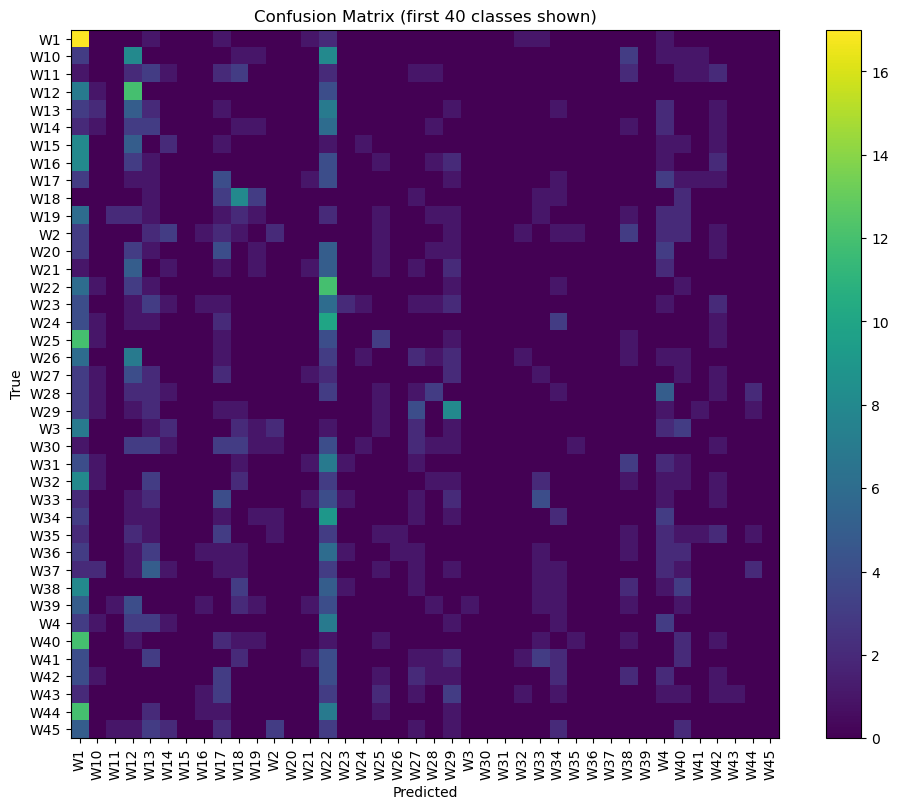

In [10]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt


META_PATH = "cnn_data/metadata.csv"
IMG_SIZE = (128, 128)   # match how you saved images
SEED = 42


def load_metadata(meta_path: str) -> pd.DataFrame:
    df = pd.read_csv(meta_path)
    required = {"writer_id", "image_path"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"metadata.csv missing columns: {missing}")

    # Keep only rows whose image exists
    df = df[df["image_path"].apply(lambda p: os.path.exists(p))].copy()
    if len(df) == 0:
        raise ValueError("No valid image paths found. Check your metadata.csv paths.")
    return df


def stratified_split(df: pd.DataFrame, label_col="writer_id", seed=SEED):
    """
    70/15/15 stratified split:
      - first split off test: 15%
      - then split remaining into train/val: val is 15/85 of remaining = 17.647% of remaining
        so overall ~70/15/15
    """
    y = df[label_col].values

    df_trainval, df_test = train_test_split(
        df, test_size=0.15, random_state=seed, stratify=y
    )

    y_trainval = df_trainval[label_col].values
    df_train, df_val = train_test_split(
        df_trainval, test_size=(0.15 / 0.85), random_state=seed, stratify=y_trainval
    )

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


def make_tf_dataset(paths, labels, img_size=IMG_SIZE, batch_size=64, training=False):
    """
    Loads grayscale PNGs -> float32 in [0,1], shape (H,W,1)
    """
    paths = np.array(paths, dtype=str)
    labels = np.array(labels, dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_png(img_bytes, channels=1)  # grayscale
        img = tf.image.resize(img, img_size, antialias=True)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 5000), seed=SEED, reshuffle_each_iteration=True)

        # Optional light augmentation (safe for handwriting)
        aug = keras.Sequential([
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomRotation(0.05),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_2layer_cnn(num_classes: int, lr=1e-3, img_size=IMG_SIZE):
    inputs = keras.Input(shape=(img_size[0], img_size[1], 1))

    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.Flatten()(x)

    # keep it simple; you can remove this Dense if you want literally only conv layers + softmax
    x = layers.Dense(128, activation="relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def evaluate_model(model, ds, y_true):
    probs = model.predict(ds, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm, y_pred


def plot_confusion_matrix(cm, class_names, max_classes=40):
    """
    Confusion matrices can be huge (many writers).
    This plots the whole thing if <= max_classes else plots only the top-left max_classes.
    """
    if cm.shape[0] > max_classes:
        cm_plot = cm[:max_classes, :max_classes]
        names_plot = class_names[:max_classes]
        title = f"Confusion Matrix (first {max_classes} classes shown)"
    else:
        cm_plot = cm
        names_plot = class_names
        title = "Confusion Matrix"

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(names_plot))
    plt.xticks(ticks, names_plot, rotation=90)
    plt.yticks(ticks, names_plot)
    plt.tight_layout()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


def main():
    # Reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    df = load_metadata(META_PATH)

    # Encode writer IDs -> integers
    le = LabelEncoder()
    df["writer_label"] = le.fit_transform(df["writer_id"].astype(str))
    class_names = le.classes_.tolist()
    num_classes = len(class_names)

    print("Total samples:", len(df))
    print("Num writers (classes):", num_classes)

    df_train, df_val, df_test = stratified_split(df, label_col="writer_id", seed=SEED)
    print("Split sizes:", len(df_train), len(df_val), len(df_test))

    # Labels for metrics need to align with the ds order
    # We'll build each ds directly from the respective df order.
    y_train = le.transform(df_train["writer_id"].astype(str))
    y_val = le.transform(df_val["writer_id"].astype(str))
    y_test = le.transform(df_test["writer_id"].astype(str))

    # Hyperparameter search (validation-based)
    grid = [
        {"lr": 1e-3, "batch_size": 64, "epochs": 10},
        {"lr": 3e-4, "batch_size": 64, "epochs": 12},
        {"lr": 1e-3, "batch_size": 128, "epochs": 10},
    ]

    best = None

    for i, hp in enumerate(grid, 1):
        print(f"\n=== Trial {i}/{len(grid)}: {hp} ===")

        train_ds = make_tf_dataset(
            df_train["image_path"].values, y_train,
            batch_size=hp["batch_size"], training=True
        )
        val_ds = make_tf_dataset(
            df_val["image_path"].values, y_val,
            batch_size=hp["batch_size"], training=False
        )

        model = build_2layer_cnn(num_classes=num_classes, lr=hp["lr"])

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy", patience=3, restore_best_weights=True
            )
        ]

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=hp["epochs"],
            callbacks=callbacks,
            verbose=1
        )

        val_acc, val_f1, _, _ = evaluate_model(model, val_ds, y_val)
        print(f"Validation accuracy: {val_acc:.4f}")
        print(f"Validation macro-F1: {val_f1:.4f}")

        score = val_f1  # choose best by macro-F1
        if best is None or score > best["score"]:
            best = {"score": score, "hp": hp}

    print("\nBest hyperparams by validation macro-F1:", best["hp"])
    print("Best validation macro-F1:", best["score"])

    # Retrain on combined train+val using best hp
    df_trainval = pd.concat([df_train, df_val], ignore_index=True)
    y_trainval = le.transform(df_trainval["writer_id"].astype(str))

    trainval_ds = make_tf_dataset(
        df_trainval["image_path"].values, y_trainval,
        batch_size=best["hp"]["batch_size"], training=True
    )
    test_ds = make_tf_dataset(
        df_test["image_path"].values, y_test,
        batch_size=best["hp"]["batch_size"], training=False
    )

    final_model = build_2layer_cnn(num_classes=num_classes, lr=best["hp"]["lr"])

    final_model.fit(
        trainval_ds,
        epochs=best["hp"]["epochs"],
        verbose=1
    )

    # Final evaluation on test EXACTLY ONCE
    test_acc, test_f1, cm, y_pred = evaluate_model(final_model, test_ds, y_test)

    print("\n=== FINAL TEST METRICS (run once) ===")
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Test macro-F1: {test_f1:.4f}")

    print("\nClassification report (macro emphasis):")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    plot_confusion_matrix(cm, class_names, max_classes=40)


if __name__ == "__main__":
    main()